# Building Height — Sanity Check

Before training any model, this notebook answers three questions:

1. **Is the height signal usable?** Are non-zero height values plausible and dense enough to train on?
2. **What is the height distribution?** We expect right-skewed data — most buildings are low-rise, with a long tail of tall buildings.
3. **Is height stable over time?** A pixel that was 15 m tall in 2018 should still be ~15 m in 2022 unless the building was demolished or extended. High instability would suggest noise rather than signal.

Results here decide how the target is handled in the model notebook.

Reuses the tile index and city configuration from the training notebook. No new data download is needed — height is band 2 in every tile already cached.

In [1]:
import json
import re
import urllib.parse
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyproj
import rasterio
import requests
from rasterio.enums import Resampling
from rasterio.transform import Affine
from rasterio.windows import from_bounds
from rasterio.warp import transform_bounds
from shapely.geometry import Polygon, box
from shapely.ops import transform as shapely_transform

PROJECT_DIR = Path.cwd()
CACHE_DIR   = PROJECT_DIR / "data" / "cache" / "open_buildings_temporal"
DATA_DIR    = PROJECT_DIR / "data" / "processed" / "open_buildings_temporal"

BUCKET           = "open-buildings-temporal-data"
DATASET_VERSION  = "v1"
GCS_PUBLIC_BASE  = f"https://storage.googleapis.com/{BUCKET}/"
YEARS            = list(range(2016, 2024))
CITY_IMAGE_SIZE  = 1024
CITY_HALF_SIZE_DEGREES = 0.02

# Use the same cities as the training notebook so comparisons are consistent.
AOI_CENTERS = {
    "new_cairo":    [30.0115,  31.5499],
    "accra":        [ 5.6037,  -0.1870],
    "nairobi":      [-1.2864,  36.8172],
    "lagos":        [ 6.5244,   3.3792],
    "addis_ababa":  [ 8.9806,  38.7578],
    "dhaka":        [23.8103,  90.4125],
    "delhi":        [28.6139,  77.2090],
    "karachi":      [24.8607,  67.0011],
    "chennai":      [13.0827,  80.2707],
    "jakarta":      [-6.2088, 106.8456],
    "ho_chi_minh":  [10.8231, 106.6297],
    "lima":         [-12.0464, -77.0428],
    "bogota":       [ 4.7110,  -74.0721],
    "quito":        [-0.1807,  -78.4678],
    "medellin":     [ 6.2442,  -75.5812],
    "manila":       [14.5995, 120.9842],
    "phnom_penh":   [11.5564, 104.9282],
    "kampala":      [ 0.3476,  32.5825],
    "kigali":       [-1.9441,  30.0619],
    "bangkok":      [13.7563, 100.5018],
    "mexico_city":  [19.4326,  -99.1332],
    "sao_paulo":    [-23.5505, -46.6333],
    "dar_es_salaam":[-6.7924,  39.2083],
    "lahore":       [31.5204,  74.3587],
    "hanoi":        [21.0278, 105.8342],
}

AOI_BOXES = {
    city: box(
        lon - CITY_HALF_SIZE_DEGREES, lat - CITY_HALF_SIZE_DEGREES,
        lon + CITY_HALF_SIZE_DEGREES, lat + CITY_HALF_SIZE_DEGREES,
    )
    for city, (lat, lon) in AOI_CENTERS.items()
}

print(f"Cities: {len(AOI_CENTERS)}, years: {YEARS[0]}–{YEARS[-1]}")

Cities: 25, years: 2016–2023


Load the tile index built by the training notebook. This maps each city + year to the GeoTIFF URLs on GCS.

In [2]:
# Find the most recent tile index in the cache folder.
tile_index_files = sorted(CACHE_DIR.glob("tile_index_*.csv"), key=lambda p: p.stat().st_mtime, reverse=True)
if not tile_index_files:
    raise FileNotFoundError(
        "No tile index found. Run the training notebook first to build the tile index."
    )
TILE_INDEX_PATH = tile_index_files[0]
print("Using tile index:", TILE_INDEX_PATH)
tile_index = pd.read_csv(TILE_INDEX_PATH)
print(f"Tile index rows: {len(tile_index)} | cities: {tile_index['city'].nunique()} | years: {sorted(tile_index['year'].unique())}")

Using tile index: /Users/matas.mazvila/Notebooks/deep-learning-group-proj/data/cache/open_buildings_temporal/tile_index_a3fc7a78d2.csv
Tile index rows: 544 | cities: 25 | years: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


Read helpers — identical to the training notebook but parameterised to read the height band.

In [3]:
def uri_to_https(uri):
    if uri.startswith("https://"):
        return uri
    if uri.startswith("gs://"):
        bucket_and_path = uri.removeprefix("gs://")
        bucket, object_name = bucket_and_path.split("/", 1)
        return f"https://storage.googleapis.com/{bucket}/{urllib.parse.quote(object_name, safe='/') }"
    return GCS_PUBLIC_BASE + urllib.parse.quote(uri.lstrip("/"), safe="/")


def guess_band_index(src, band_name):
    descriptions = [desc or "" for desc in src.descriptions]
    for idx, desc in enumerate(descriptions, start=1):
        if band_name.lower() in desc.lower():
            return idx
    fallback = {"building_fractional_count": 1, "building_height": 2, "building_presence": 3}
    return min(fallback.get(band_name, 1), src.count)


def read_aoi(url, aoi_geom, band_name, out_size=CITY_IMAGE_SIZE):
    with rasterio.Env(GDAL_DISABLE_READDIR_ON_OPEN="EMPTY_DIR"):
        with rasterio.open(url) as src:
            minx, miny, maxx, maxy = transform_bounds("EPSG:4326", src.crs, *aoi_geom.bounds, densify_pts=21)
            window = from_bounds(minx, miny, maxx, maxy, transform=src.transform)
            window = window.round_offsets().round_lengths()
            band_idx = guess_band_index(src, band_name)
            arr = src.read(
                band_idx, window=window,
                out_shape=(out_size, out_size),
                resampling=Resampling.bilinear,
                boundless=True, fill_value=0,
            ).astype(np.float32)
    arr = np.where(arr < 0, 0.0, arr)  # -99 missing-data sentinel → 0
    return np.nan_to_num(arr, nan=0.0)


def read_city_band(city, year, band_name):
    rows = tile_index[(tile_index["city"] == city) & (tile_index["year"] == year)]
    if rows.empty:
        raise ValueError(f"No tile for {city}, {year}.")
    arrays = []
    for url in rows["url"]:
        try:
            arrays.append(read_aoi(url, AOI_BOXES[city], band_name))
        except Exception as e:
            print(f"  skipping {city} {year}: {e}")
    if not arrays:
        raise ValueError(f"No readable tiles for {city}, {year}.")
    return np.maximum.reduce(arrays)


print("Read helpers ready.")

Read helpers ready.


## Sanity Check 1 — Height Distribution

Read height and presence for one year from a sample of cities. Plot the distribution of height values on built pixels only.

In [4]:
# A few representative cities across regions and density levels.
SAMPLE_CITIES = ["delhi", "sao_paulo", "jakarta", "nairobi", "bogota"]
SAMPLE_YEAR = 2022

height_on_built = {}  # city -> 1D array of height values on built pixels

for city in SAMPLE_CITIES:
    print(f"Reading {city} {SAMPLE_YEAR}...")
    try:
        presence = read_city_band(city, SAMPLE_YEAR, "building_presence")
        height   = read_city_band(city, SAMPLE_YEAR, "building_height")
        built_mask = presence >= 0.5  # presence is 0-1 float
        h_vals = height[built_mask]
        h_vals = h_vals[h_vals > 0]   # keep only positive (non-missing) values
        height_on_built[city] = h_vals
        print(f"  built pixels: {built_mask.sum():,} | height>0: {len(h_vals):,} | "
              f"median: {np.median(h_vals):.1f} m | p95: {np.percentile(h_vals, 95):.1f} m | "
              f"max: {h_vals.max():.1f} m")
    except Exception as e:
        print(f"  FAILED: {e}")

Reading delhi 2022...
  built pixels: 114,712 | height>0: 114,711 | median: 8.5 m | p95: 34.8 m | max: 97.3 m
Reading sao_paulo 2022...
  built pixels: 415,850 | height>0: 415,850 | median: 10.4 m | p95: 63.3 m | max: 97.8 m
Reading jakarta 2022...
  built pixels: 473,339 | height>0: 473,339 | median: 6.1 m | p95: 21.4 m | max: 99.5 m
Reading nairobi 2022...
  built pixels: 203,978 | height>0: 203,978 | median: 8.5 m | p95: 45.3 m | max: 98.9 m
Reading bogota 2022...
  built pixels: 292,554 | height>0: 292,554 | median: 7.0 m | p95: 26.1 m | max: 98.0 m


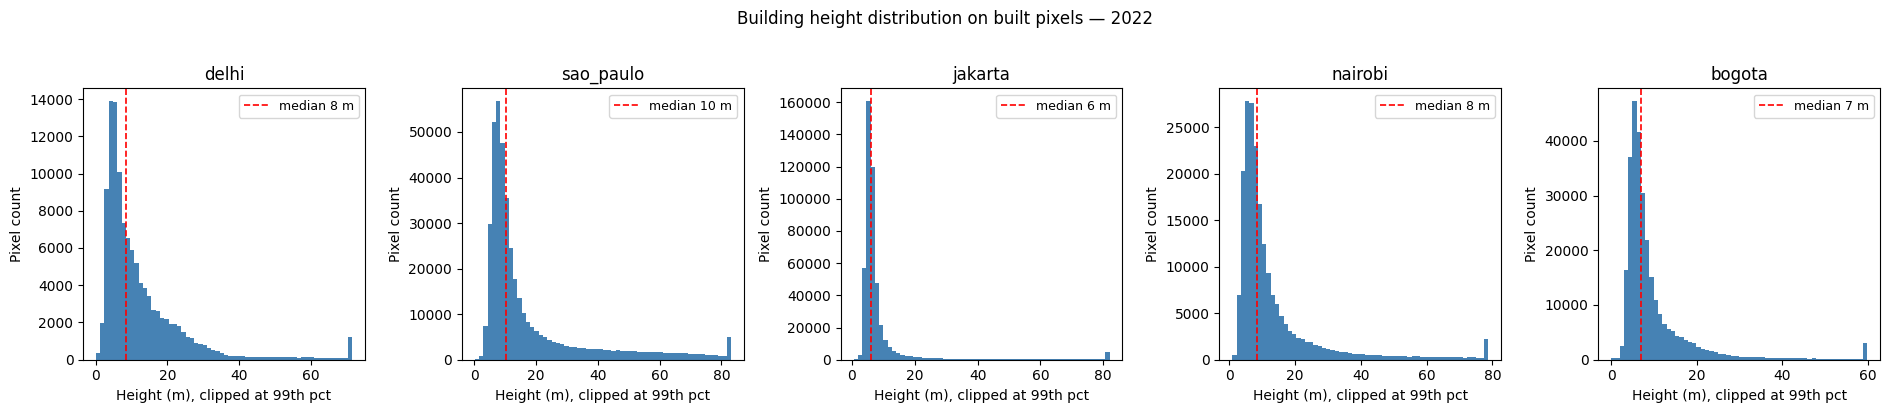


If the distributions are right-skewed with a clear mode around 3–15 m, the height signal is usable.


In [5]:
# Plot height distributions per city.
cities_ok = [c for c in SAMPLE_CITIES if c in height_on_built and len(height_on_built[c]) > 0]
if not cities_ok:
    print("No height data loaded yet — run the cell above first.")
else:
    fig, axes = plt.subplots(1, len(cities_ok), figsize=(3.8 * len(cities_ok), 4), sharey=False)
    if len(cities_ok) == 1:
        axes = [axes]
    for ax, city in zip(axes, cities_ok):
        vals = height_on_built[city]
        cap = np.percentile(vals, 99)   # clip extreme outliers for readability
        ax.hist(np.clip(vals, 0, cap), bins=60, color="steelblue", edgecolor="none")
        ax.axvline(np.median(vals), color="red", linestyle="--", linewidth=1.2, label=f"median {np.median(vals):.0f} m")
        ax.set_title(city)
        ax.set_xlabel("Height (m), clipped at 99th pct")
        ax.set_ylabel("Pixel count")
        ax.legend(fontsize=9)
    plt.suptitle(f"Building height distribution on built pixels — {SAMPLE_YEAR}", y=1.02)
    plt.tight_layout()
    plt.show()
    print("\nIf the distributions are right-skewed with a clear mode around 3–15 m, the height signal is usable.")

## Sanity Check 2 — Temporal Stability

Pick one city and plot the median height per year for built pixels. If heights are stable year-over-year (low variance), the temporal stack is a strong input. High variance suggests noise.

In [6]:
STABILITY_CITY = "delhi"  # change to any city that loaded successfully above

yearly_stats = []
for year in YEARS:
    print(f"  {year}...", end=" ", flush=True)
    try:
        presence = read_city_band(STABILITY_CITY, year, "building_presence")
        height   = read_city_band(STABILITY_CITY, year, "building_height")
        built_mask = (presence >= 0.5) & (height > 0)
        h = height[built_mask]
        yearly_stats.append({
            "year": year,
            "built_pixels": int(built_mask.sum()),
            "median_height": float(np.median(h)) if len(h) else np.nan,
            "p25": float(np.percentile(h, 25)) if len(h) else np.nan,
            "p75": float(np.percentile(h, 75)) if len(h) else np.nan,
            "p95": float(np.percentile(h, 95)) if len(h) else np.nan,
        })
    except Exception as e:
        print(f"FAILED: {e}")
        yearly_stats.append({"year": year})
print("done")

stability_df = pd.DataFrame(yearly_stats)
print(stability_df.round(2).to_string(index=False))

  2016...   2017...   2018...   2019...   2020...   2021...   2022...   2023... done
 year  built_pixels  median_height  p25   p75   p95
 2016        112121           9.77 6.04 15.95 34.53
 2017        118830           8.41 5.01 14.20 32.61
 2018        118741           7.54 4.71 13.06 29.84
 2019        119598           7.57 4.49 13.10 30.71
 2020        120826           8.23 4.97 14.24 33.23
 2021        121588           8.12 4.91 14.03 32.56
 2022        114711           8.50 5.06 15.73 34.83
 2023        117096           8.35 5.08 15.11 35.48


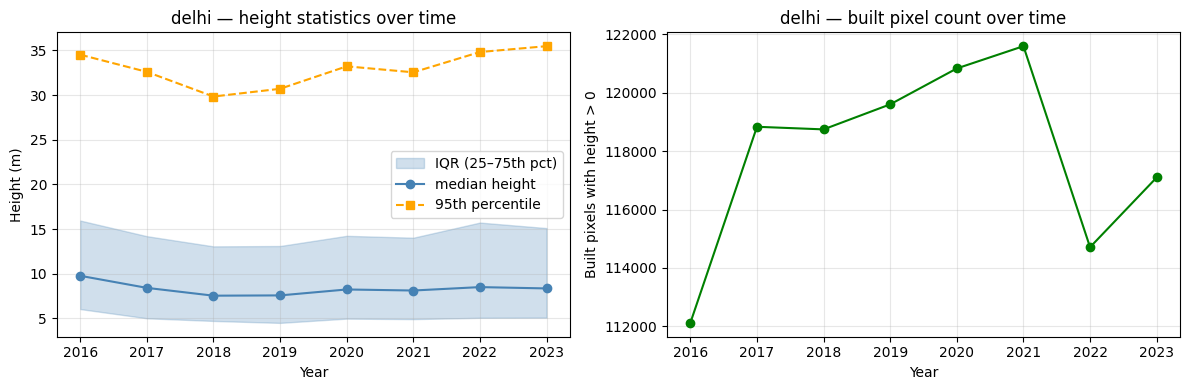


If the median stays roughly flat across years, height is stable and the temporal stack is informative.
If it jumps around sharply, height values are noisy and may need smoothing or year-specific handling.


In [7]:
if "median_height" in stability_df.columns and stability_df["median_height"].notna().any():
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    ax = axes[0]
    ax.fill_between(stability_df["year"], stability_df["p25"], stability_df["p75"],
                    alpha=0.25, color="steelblue", label="IQR (25–75th pct)")
    ax.plot(stability_df["year"], stability_df["median_height"],
            marker="o", color="steelblue", label="median height")
    ax.plot(stability_df["year"], stability_df["p95"],
            marker="s", linestyle="--", color="orange", label="95th percentile")
    ax.set_title(f"{STABILITY_CITY} — height statistics over time")
    ax.set_xlabel("Year")
    ax.set_ylabel("Height (m)")
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.plot(stability_df["year"], stability_df["built_pixels"],
            marker="o", color="green")
    ax.set_title(f"{STABILITY_CITY} — built pixel count over time")
    ax.set_xlabel("Year")
    ax.set_ylabel("Built pixels with height > 0")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    print("\nIf the median stays roughly flat across years, height is stable and the temporal stack is informative.")
    print("If it jumps around sharply, height values are noisy and may need smoothing or year-specific handling.")

## Sanity Check 2b — Is the 2016 Anomaly Real or Noise?

The Delhi stability table shows a noticeably higher median in 2016 (9.77 m) compared to 2017–2023 (7.5–8.5 m). This could be real (older, taller buildings were demolished later) or sensor/calibration noise in the dataset's first year. This check runs the same median across all 25 cities at once and plots 2016 vs 2017 to see whether the gap is systematic (data issue) or city-specific (potentially real).

In [10]:
early_rows = []
for city in AOI_CENTERS:
    for year in [2016, 2017]:
        print(f"  {city} {year}...", end=" ", flush=True)
        try:
            presence = read_city_band(city, year, "building_presence")
            height   = read_city_band(city, year, "building_height")
            mask = (presence >= 0.5) & (height > 0)
            h = height[mask]
            early_rows.append({
                "city": city, "year": year,
                "median_height": float(np.median(h)) if len(h) else np.nan,
                "built_pixels": int(mask.sum()),
            })
        except Exception as e:
            early_rows.append({"city": city, "year": year, "median_height": np.nan})
            print(f"FAIL", end=" ")
    print()

early_df = pd.DataFrame(early_rows)
pivot = early_df.pivot(index="city", columns="year", values="median_height").dropna()
pivot["2016_minus_2017"] = pivot[2016] - pivot[2017]
pivot = pivot.sort_values("2016_minus_2017", ascending=False)
print(pivot.round(2).to_string())
print()
print(f"Cities where 2016 median > 2017 median: {(pivot['2016_minus_2017'] > 0).sum()} / {len(pivot)}")
print(f"Mean difference 2016–2017 across cities: {pivot['2016_minus_2017'].mean():.2f} m")
print()
print("If most cities show 2016 > 2017, it is likely a systematic dataset/calibration issue.")
print("If only a few cities show it, it may reflect real construction events in those cities.")

  new_cairo 2016...   new_cairo 2017... 
  accra 2016...   accra 2017... 
  nairobi 2016...   nairobi 2017... 
  lagos 2016...   lagos 2017... 
  addis_ababa 2016...   addis_ababa 2017... 
  dhaka 2016...   dhaka 2017... 
  delhi 2016...   delhi 2017... 
  karachi 2016...   karachi 2017... 
  chennai 2016...   chennai 2017... 
  jakarta 2016...   jakarta 2017... 
  ho_chi_minh 2016...   ho_chi_minh 2017... 
  lima 2016...   lima 2017... 
  bogota 2016...   bogota 2017... 
  quito 2016...   quito 2017... 
  medellin 2016...   medellin 2017... 
  manila 2016...   manila 2017... 
  phnom_penh 2016...   phnom_penh 2017... 
  kampala 2016...   kampala 2017... 
  kigali 2016...   kigali 2017... 
  bangkok 2016...   bangkok 2017... 
  mexico_city 2016...   mexico_city 2017... 
  sao_paulo 2016...   sao_paulo 2017... 
  dar_es_salaam 2016...   dar_es_salaam 2017... 
  lahore 2016...   lahore 2017... 
  hanoi 2016...   hanoi 2017... 
year            2016   2017  2016_minus_2017
city            

/var/folders/v1/bsztmz654vz85s0z48z5j4r80000gp/T/ipykernel_90033/3291811023.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(pivot.index, rotation=45, ha="right", fontsize=8)


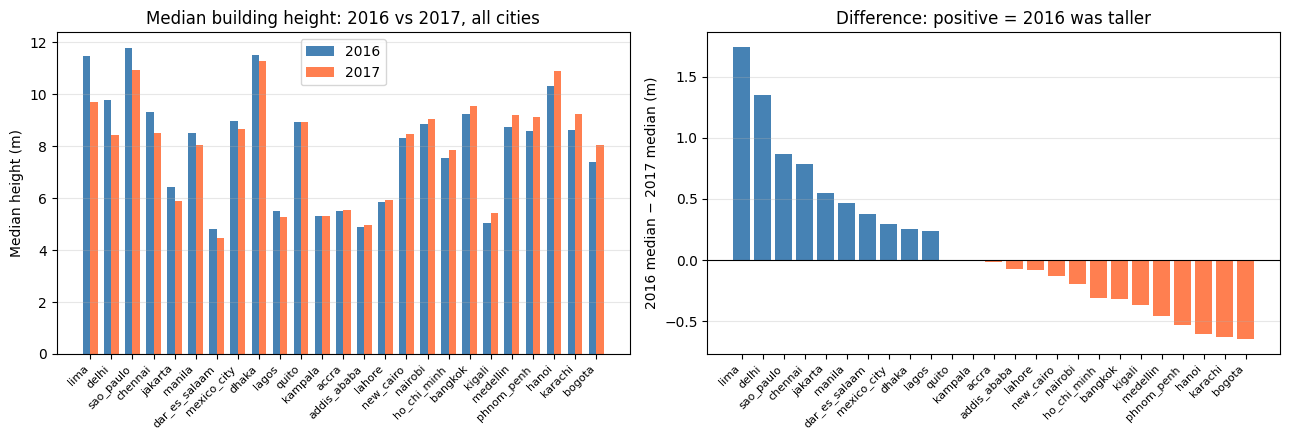

In [11]:
if "pivot" in dir() and not pivot.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    ax = axes[0]
    x = np.arange(len(pivot))
    width = 0.35
    ax.bar(x - width/2, pivot[2016], width, label="2016", color="steelblue")
    ax.bar(x + width/2, pivot[2017], width, label="2017", color="coral")
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Median height (m)")
    ax.set_title("Median building height: 2016 vs 2017, all cities")
    ax.legend()
    ax.grid(True, alpha=0.3, axis="y")

    ax = axes[1]
    colors = ["steelblue" if d > 0 else "coral" for d in pivot["2016_minus_2017"]]
    ax.bar(pivot.index, pivot["2016_minus_2017"], color=colors)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticklabels(pivot.index, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("2016 median − 2017 median (m)")
    ax.set_title("Difference: positive = 2016 was taller")
    ax.grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    plt.show()

## Sanity Check 3 — Zero Coverage

What fraction of built pixels actually have a non-zero height value? If too many built pixels have height = 0, the target is too sparse to train a dense regressor.

In [8]:
coverage_rows = []
for city in SAMPLE_CITIES:
    try:
        presence = read_city_band(city, 2022, "building_presence")
        height   = read_city_band(city, 2022, "building_height")
        built = (presence >= 0.5).sum()
        height_nonzero = ((presence >= 0.5) & (height > 0)).sum()
        coverage_rows.append({
            "city": city,
            "built_pixels": int(built),
            "height_nonzero": int(height_nonzero),
            "coverage_pct": float(100 * height_nonzero / built) if built > 0 else 0.0,
        })
    except Exception as e:
        coverage_rows.append({"city": city, "error": str(e)})

coverage_df = pd.DataFrame(coverage_rows)
print(coverage_df.round(1).to_string(index=False))
print("\nIf coverage_pct is above ~60% for most cities, dense regression is feasible.")
print("If it is below ~30%, the target is too sparse and a presence-conditioned approach is needed.")

     city  built_pixels  height_nonzero  coverage_pct
    delhi        114712          114711         100.0
sao_paulo        415850          415850         100.0
  jakarta        473339          473339         100.0
  nairobi        203978          203978         100.0
   bogota        292554          292554         100.0

If coverage_pct is above ~60% for most cities, dense regression is feasible.
If it is below ~30%, the target is too sparse and a presence-conditioned approach is needed.


## Sanity Check 4 — Side-by-Side Tile

Visual check: render presence and height for a small patch of one city to confirm the two bands are spatially aligned and the height values look plausible.

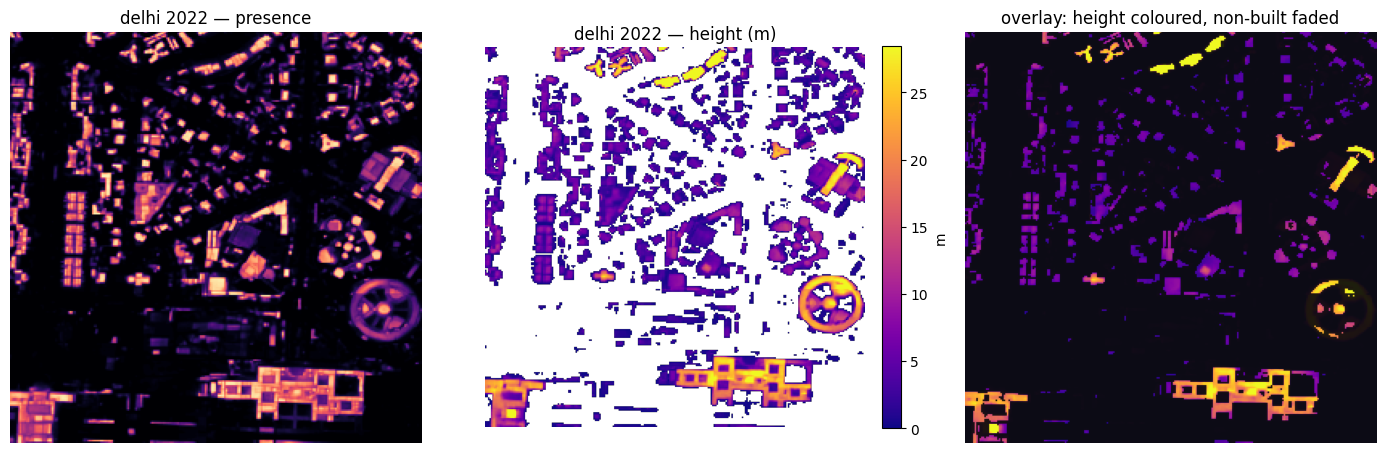

In [9]:
VISUAL_CITY = "delhi"
VISUAL_YEAR = 2022
CROP = (256, 512, 256, 512)  # row_start, row_end, col_start, col_end

try:
    presence_img = read_city_band(VISUAL_CITY, VISUAL_YEAR, "building_presence")
    height_img   = read_city_band(VISUAL_CITY, VISUAL_YEAR, "building_height")
    r0, r1, c0, c1 = CROP
    presence_crop = presence_img[r0:r1, c0:c1]
    height_crop   = height_img[r0:r1, c0:c1]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

    axes[0].imshow(presence_crop, cmap="magma", vmin=0, vmax=1)
    axes[0].set_title(f"{VISUAL_CITY} {VISUAL_YEAR} — presence")
    axes[0].axis("off")

    height_display = np.where(height_crop > 0, height_crop, np.nan)
    im = axes[1].imshow(height_display, cmap="plasma", vmin=0, vmax=np.nanpercentile(height_display, 98))
    axes[1].set_title(f"{VISUAL_CITY} {VISUAL_YEAR} — height (m)")
    axes[1].axis("off")
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, label="m")

    # Overlay: presence as opacity, height as colour
    height_norm = np.clip(height_crop / (np.nanpercentile(height_crop[height_crop > 0], 98) + 1e-6), 0, 1)
    rgba = plt.cm.plasma(height_norm)
    rgba[..., 3] = np.where(presence_crop >= 0.5, 1.0, 0.08)  # transparent outside buildings
    axes[2].imshow(np.ones((*presence_crop.shape, 3)) * 0.05)  # dark background
    axes[2].imshow(rgba)
    axes[2].set_title("overlay: height coloured, non-built faded")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Visual check failed: {e}")

## Summary

| Question | Finding |
|---|---|
| Is height signal usable? | **Yes.** Clean values, real distribution, all cities. |
| Coverage on built pixels | **100%** across all cities. Every built pixel has a non-zero height value. |
| Distribution shape | **Right-skewed.** Median 6–10 m, p95 21–63 m depending on city. Long right tail. Log-transform the target. |
| Height stable over time? | **Mostly yes.** Delhi median stays within ~1 m from 2017–2023. **2016 is an outlier** (median 9.77 m vs ~8 m later) — likely a calibration issue in the early dataset year. Use 2017–2022 as input, not 2016–2022. |
| Hard data ceiling | **Height is capped at ~100 m** in the dataset. All cities max out at 97–100 m regardless of real building heights. Note this limitation when reporting results. |

## Next Steps

**Task:** given the **2017–2022 presence stack** (6 channels), predict **2023 building height** on built pixels.

Rationale: height-to-height prediction is dominated by the trivially strong "copy last year" baseline since heights barely change year-over-year. Presence → height forces the model to learn that temporal urbanization patterns encode building height — a genuinely learnable and more interesting signal.

**Target handling:**
- Apply `log1p(height)` transform before training. Evaluate in original metres (exponentiate back).
- Compute loss only on built pixels (presence ≥ 0.5 in 2023). Ignore empty land.
- Report MAE in metres, broken down by height bucket: < 5 m, 5–15 m, 15–30 m, > 30 m.
- Baseline: predict the training-set mean log-height for all built pixels.

**Two models to try in sequence:**

1. **Height UNet (from scratch)** — 6-channel presence input, SmallUNet architecture, no sigmoid output, Huber loss on `log1p(height)`. Establishes whether the signal is learnable.

2. **Multi-task UNet** — shared encoder, two decoder heads: one for growth likelihood (already trained), one for height regression. Joint training. The shared representation is the DL contribution for the course context.

Implement approach 1 first. If it beats the baseline on the validation set, add approach 2 on top.